In [1]:
import numpy as np
import pandas as pd

features = np.load("poster_features_pca150.npy")
genre_matrix = np.load("genre_matrix.npy")
train_idx = np.load("train_idx.npy")
val_idx = np.load("val_idx.npy")
test_idx = np.load("test_idx.npy")
feature_ids = np.load("poster_feature_ids.npy")

df = pd.read_csv("movie_genre_metadata_clean.csv")

print("Features:", features.shape)
print("Genre matrix:", genre_matrix.shape)
print("Train/Val/Test:", len(train_idx), len(val_idx), len(test_idx))

Features: (3985, 150)
Genre matrix: (3985, 19)
Train/Val/Test: 3188 398 399


In [2]:
print("ID redoslijed se slaže:", np.array_equal(feature_ids, df["id"].values))

ID redoslijed se slaže: True


In [3]:
X_train, y_train = features[train_idx], genre_matrix[train_idx]
X_val, y_val = features[val_idx], genre_matrix[val_idx]
X_test, y_test = features[test_idx], genre_matrix[test_idx]

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (3188, 150) (3188, 19)
Val: (398, 150) (398, 19)
Test: (399, 150) (399, 19)


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Standardizacija gotova.")
print("Mean:", X_train_scaled.mean().round(3), "Std:", X_train_scaled.std().round(3))

Standardizacija gotova.
Mean: -0.0 Std: 1.0


In [5]:
from sklearn.metrics import f1_score, precision_score, recall_score, hamming_loss
import time

def evaluate_model(model, X_test, y_test, model_name):
    start = time.time()
    y_pred = model.predict(X_test)
    inference_time = time.time() - start
    
    results = {
        "model": model_name,
        "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "f1_micro": f1_score(y_test, y_pred, average="micro", zero_division=0),
        "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "hamming_loss": hamming_loss(y_test, y_pred),
        "inference_time": inference_time
    }
    return results, y_pred

all_results = []
print("Funkcija definirana.")

Funkcija definirana.


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier

lr_model = MultiOutputClassifier(
    LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
)

start = time.time()
lr_model.fit(X_train_scaled, y_train)
train_time = time.time() - start

print(f"Treniranje gotovo u {train_time:.1f}s")

results, y_pred_lr = evaluate_model(lr_model, X_test_scaled, y_test, "Logistic Regression")
results["train_time"] = train_time
all_results.append(results)
print(results)

Treniranje gotovo u 2.2s
{'model': 'Logistic Regression', 'f1_macro': 0.36567873268566825, 'f1_micro': 0.4571244358478401, 'precision_macro': 0.28716343745061396, 'recall_macro': 0.5606706599049133, 'hamming_loss': 0.22213428307611133, 'inference_time': 0.0219573974609375, 'train_time': 2.1974973678588867}


In [7]:
from sklearn.ensemble import RandomForestClassifier

rf_model = MultiOutputClassifier(
    RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=2)
)

start = time.time()
rf_model.fit(X_train_scaled, y_train)
train_time = time.time() - start

print(f"Treniranje gotovo u {train_time:.1f}s")

results, y_pred_rf = evaluate_model(rf_model, X_test_scaled, y_test, "Random Forest")
results["train_time"] = train_time
all_results.append(results)
print(results)

Treniranje gotovo u 178.2s
{'model': 'Random Forest', 'f1_macro': 0.0622014935191531, 'f1_micro': 0.10329474621549421, 'precision_macro': 0.36859305125558994, 'recall_macro': 0.03491737918573584, 'hamming_loss': 0.13283208020050125, 'inference_time': 0.955211877822876, 'train_time': 178.20025753974915}


In [8]:
from sklearn.svm import SVC

svm_model = MultiOutputClassifier(
    SVC(class_weight="balanced", kernel="rbf", probability=False, random_state=42)
)

start = time.time()
svm_model.fit(X_train_scaled, y_train)
train_time = time.time() - start

print(f"Treniranje gotovo u {train_time:.1f}s")

results, y_pred_svm = evaluate_model(svm_model, X_test_scaled, y_test, "SVM")
results["train_time"] = train_time
all_results.append(results)
print(results)

Treniranje gotovo u 14.1s
{'model': 'SVM', 'f1_macro': 0.3303207445145907, 'f1_micro': 0.5091267883571781, 'precision_macro': 0.3463813582054438, 'recall_macro': 0.32332214390914377, 'hamming_loss': 0.13124917557050522, 'inference_time': 4.129894018173218, 'train_time': 14.108635663986206}


In [9]:
import sys
!{sys.executable} -m pip install xgboost --quiet

In [10]:
from xgboost import XGBClassifier

xgb_model = MultiOutputClassifier(
    XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=2)
)

start = time.time()
xgb_model.fit(X_train_scaled, y_train)
train_time = time.time() - start

print(f"Treniranje gotovo u {train_time:.1f}s")

results, y_pred_xgb = evaluate_model(xgb_model, X_test_scaled, y_test, "XGBoost")
results["train_time"] = train_time
all_results.append(results)
print(results)

Treniranje gotovo u 132.8s
{'model': 'XGBoost', 'f1_macro': 0.23193574429961517, 'f1_micro': 0.3941990771259064, 'precision_macro': 0.38952329128853247, 'recall_macro': 0.17905012040666066, 'hamming_loss': 0.1212241129138636, 'inference_time': 0.03601384162902832, 'train_time': 132.8395278453827}


In [11]:
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    max_iter=300,
    random_state=42,
    early_stopping=True
)

start = time.time()
mlp_model.fit(X_train_scaled, y_train)
train_time = time.time() - start

print(f"Treniranje gotovo u {train_time:.1f}s")

results, y_pred_mlp = evaluate_model(mlp_model, X_test_scaled, y_test, "MLP")
results["train_time"] = train_time
all_results.append(results)
print(results)

Treniranje gotovo u 1.2s
{'model': 'MLP', 'f1_macro': 0.2540625456355764, 'f1_micro': 0.40422885572139305, 'precision_macro': 0.3784054102167697, 'recall_macro': 0.2033357408588057, 'hamming_loss': 0.12636855296135074, 'inference_time': 0.0016586780548095703, 'train_time': 1.2157740592956543}


In [12]:
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values("f1_macro", ascending=False)
print(results_df.to_string(index=False))

              model  f1_macro  f1_micro  precision_macro  recall_macro  hamming_loss  inference_time  train_time
Logistic Regression  0.365679  0.457124         0.287163      0.560671      0.222134        0.021957    2.197497
                SVM  0.330321  0.509127         0.346381      0.323322      0.131249        4.129894   14.108636
                MLP  0.254063  0.404229         0.378405      0.203336      0.126369        0.001659    1.215774
            XGBoost  0.231936  0.394199         0.389523      0.179050      0.121224        0.036014  132.839528
      Random Forest  0.062201  0.103295         0.368593      0.034917      0.132832        0.955212  178.200258


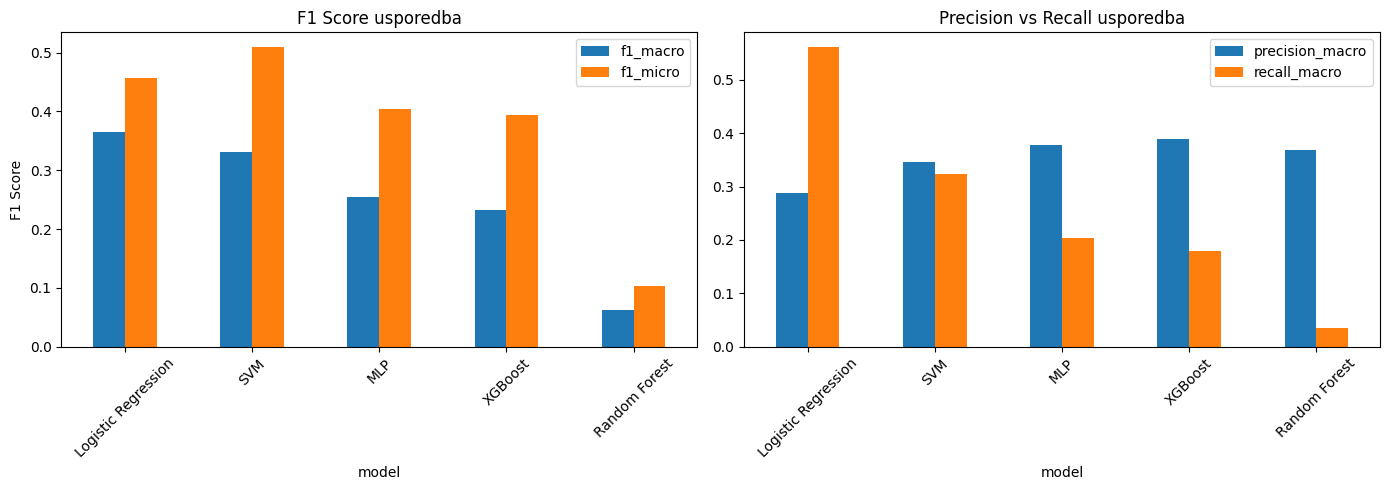

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14,5))

results_df.plot(x="model", y=["f1_macro", "f1_micro"], kind="bar", ax=axes[0])
axes[0].set_title("F1 Score usporedba")
axes[0].set_ylabel("F1 Score")
axes[0].tick_params(axis='x', rotation=45)

results_df.plot(x="model", y=["precision_macro", "recall_macro"], kind="bar", ax=axes[1])
axes[1].set_title("Precision vs Recall usporedba")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("model_comparison.png")
plt.show()

In [14]:
import joblib

results_df.to_csv("model_comparison_results.csv", index=False)

joblib.dump(lr_model, "model_logistic_regression.pkl")
joblib.dump(rf_model, "model_random_forest.pkl")
joblib.dump(svm_model, "model_svm.pkl")
joblib.dump(xgb_model, "model_xgboost.pkl")
joblib.dump(mlp_model, "model_mlp.pkl")
joblib.dump(scaler, "feature_scaler.pkl")

print("Svi modeli i rezultati spremljeni.")

Svi modeli i rezultati spremljeni.
